# Experiment 1: Baseline Diffusion
**Drug Modeled:** Gefitinib

**Condition Tested:** Diffusion profiles with varying changes: baseline, time variation, diffusion coefficient variation

**Research Question:** How does gefitinib diffuse through tumor tissue?

## Introduction

Before investigating EGFR inhibition, signaling activity, and proliferation response, it is necessary to understand the underlying transport process that determines local drug exposure. Drug molecules must first diffuse through tissue before they can interact with cellular targets.

Diffusion is governed by Fick’s second law:

$$
\frac{\partial C}{\partial t}

D \frac{\partial^2 C}{\partial x^2}
$$

where $C$ is drug concentration, $t$ is time, $x$ is tissue depth, and $D$ is the effective diffusion coefficient.

The analytical solution predicts that diffusion produces spatial concentration gradients, with the highest concentrations occurring near the source and lower concentrations observed at increasing tissue depths. These gradients evolve over time and depend strongly on the diffusion coefficient of the surrounding tissue.

Objective

This experiment establishes a baseline model of gefitinib transport in homogeneous tissue by examining:

1. A baseline concentration profile at a fixed time point.
2. The effect of diffusion time on concentration distribution.
3. The effect of varying diffusion coefficients on penetration depth.

Together, these simulations provide a foundation for subsequent experiments that incorporate tissue heterogeneity, EGFR inhibition, and downstream proliferation responses.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Effective diffusion coefficient for gefitinib in tumor tissue
# Literature-derived range for small-molecule transport in solid tumors:
# 10^-7 to 10^-6 cm^2 /s
# Baseline value chosen for simulation
D = 5e-7            # cm^2 /s

# Normalized source concentration
# Relative concentration used to study spatial gradients
C0 = 1.0            # arbitrary units

# Tissue depth range
# 0-2 mm into tumor tissue
x = np.linspace(0, 0.2, 1000)       # cm

# Single time point
# 1 hour after drug exposure
t = 3600            # seconds

In [2]:
import numpy as np

# Analytical Solution to Fick's Second Law

# Fundamental solution of the 1D diffusion equation

# Represents spatial redistribution of drug from an initial source

normalization = 1 / np.sqrt(4 * np.pi * D * t)

# Gefitinib concentration profile as a function of depth

C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))

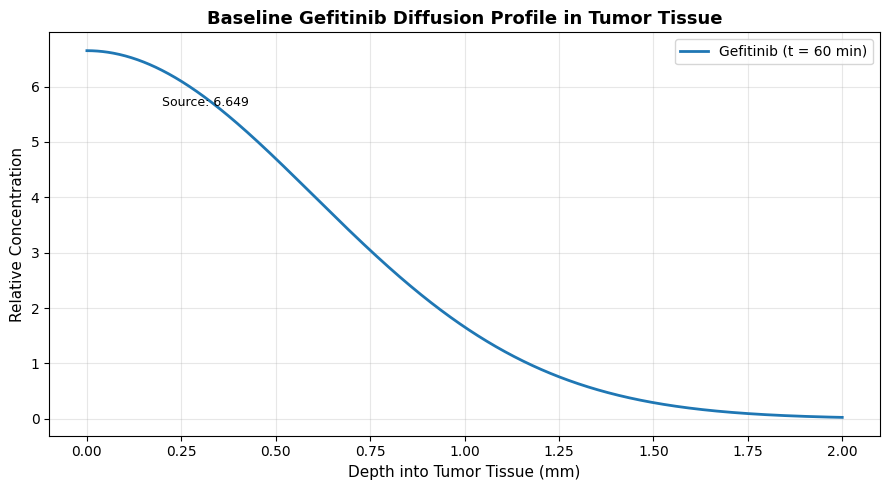

In [3]:
import os
os.makedirs('figures', exist_ok = True)

# Plot

fig, ax = plt.subplots(figsize = (9,5))

ax.plot(x * 10, C, linewidth = 2, label = 'Gefitinib (t = 60 min)')

# Labels and formatting
ax.set_title('Baseline Gefitinib Diffusion Profile in Tumor Tissue', 
                fontsize = 13, fontweight = 'bold')


ax.set_xlabel('Depth into Tumor Tissue (mm)', fontsize = 11)

ax.set_ylabel('Relative Concentration', fontsize = 11)

ax.legend(fontsize = 10)
ax.grid(True, alpha = 0.3)

# Annotate peak concentration

peak = C[0]

ax.annotate(f'Source: {peak:0.3f}', xy = (0, peak), xytext = (0.2, peak * 0.85), fontsize = 9)

plt.tight_layout()
plt.savefig('figures/exp01_baseline.png', dpi = 150, bbox_inches = 'tight')
plt.show()


## Figure 1A

**Figure 1A.** Baseline gefitinib concentration profile in homogeneous tumor tissue predicted by the analytical solution to Fick’s second law. Drug concentration decreases with increasing tissue depth, producing a spatial gradient that reflects diffusion away from the source.

### Observations

* Maximum concentration occurs at the source boundary.
* Concentration decreases continuously with increasing depth.
* The majority of drug remains localized near the source region.

### Interpretation

The diffusion process naturally generates concentration gradients even in homogeneous tissue. As a result, cells located at different depths are exposed to different local drug concentrations, potentially leading to heterogeneous biological responses.

### Discussion

This baseline profile represents a single time point. However, diffusion is a dynamic process, and concentration distributions evolve over time. The next experiment investigates how these gradients change as diffusion progresses.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Parameters

# Effective diffusion coefficient for gefitinib in tumor tissue
# Representative value within the literature range (~10^-7 to 10^-6 cm²/s)
D = 5e-7             # cm²/s

# Normalized source concentration
C0 = 1.0             # arbitrary units

# Tissue depth range
# 0–2 mm into tumor tissue
x = np.linspace(0, 0.2, 1000)    # cm

# Time points for diffusion evolution
times_min = [10, 30, 60, 120]    # minutes
times_sec = [t * 60 for t in times_min]

# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

In [5]:
# Analytical Solution Across Time Points 

profiles = []

for t in times_sec:

    normalization = 1 / np.sqrt(4 * np.pi * D * t)

    C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))

    profiles.append(C)

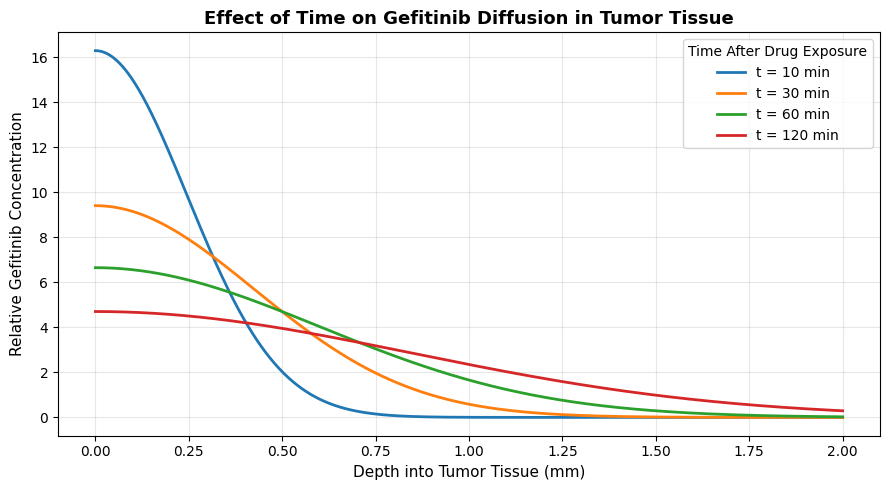

In [6]:
# Plot

fig, ax = plt.subplots(figsize=(9, 5))

for i, (C, t_min) in enumerate(zip(profiles, times_min)):
    ax.plot(x * 10, C, color=colors[i],
                linewidth=2, label=f't = {t_min} min')

ax.set_title('Effect of Time on Gefitinib Diffusion in Tumor Tissue', fontsize=13, fontweight='bold')

ax.set_xlabel('Depth into Tumor Tissue (mm)', fontsize=11)

ax.set_ylabel('Relative Gefitinib Concentration', fontsize=11)

ax.legend(fontsize=10, title='Time After Drug Exposure')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/exp01_time_variation.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 1B

**Figure 1B.** Simulated gefitinib concentration profiles at multiple time points. As diffusion progresses, concentration gradients broaden and penetrate deeper into tissue while peak concentration decreases due to mass conservation.

### Observations

* Early time points exhibit steep concentration gradients near the source.
* Later time points show increased penetration depth.
* Peak concentration decreases as the drug spreads throughout the tissue.

### Interpretation

The temporal evolution of diffusion redistributes drug molecules across a larger spatial region. While deeper tissue receives greater exposure over time, local concentrations near the source decrease as the drug disperses.

### Discussion

Time is not the only factor influencing transport. Drug penetration also depends strongly on the effective diffusion coefficient of the tissue environment. The next experiment examines how varying diffusivity alters concentration distributions.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Parameters

# Effective diffusion coefficient for gefitinib in tumor tissue
# Representative baseline within reported small-molecule tumor transport range
D_baseline = 5e-7      # cm²/s

# Physiologically plausible diffusion range
D_values = [
    1e-7,   # Highly diffusion-limited tissue
    2.5e-7, # Dense tumor tissue
    5e-7,   # Baseline
    7.5e-7, # Moderately permeable tissue
    1e-6    # Highly permeable tissue
]

D_labels = [
    r'D = $1\times10^{-7}$ cm²/s',
    r'D = $2.5\times10^{-7}$ cm²/s',
    r'D = $5\times10^{-7}$ cm²/s',
    r'D = $7.5\times10^{-7}$ cm²/s',
    r'D = $1\times10^{-6}$ cm²/s'
]

# Normalized source concentration
C0 = 1.0

# Tissue depth range
x = np.linspace(0, 0.2, 1000)   # cm (0–2 mm)

# Fixed time point
t = 3600                        # seconds (60 min)

# Color palette
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

In [8]:
# Gefitinib Concentration Profiles Across Diffusion Coefficients

profiles = []

for D in D_values:
    normalization = 1 / np.sqrt(4 * np.pi * D * t)

    C = C0 * normalization * np.exp(
        -(x**2) / (4 * D * t)
    )

    profiles.append(C)

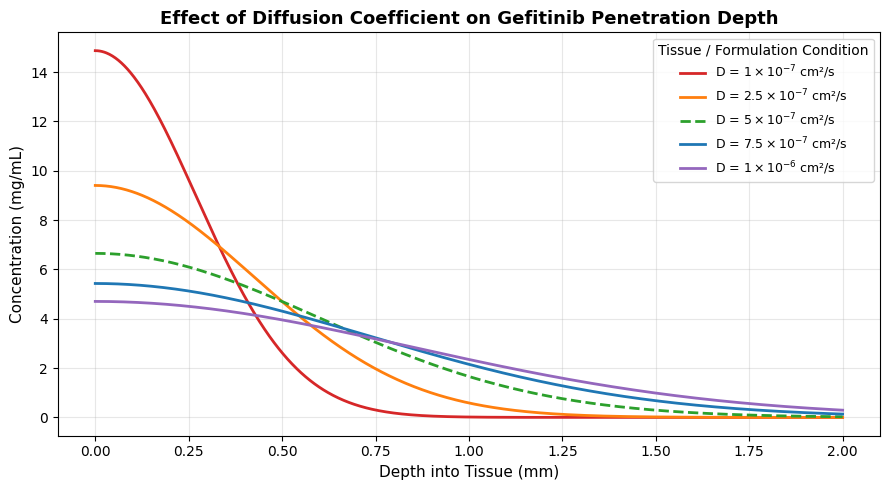

In [9]:
# Plot 

fig, ax = plt.subplots(figsize=(9, 5))

for i, (C, label) in enumerate(zip(profiles, D_labels)):
    linestyle = '--' if i == 2 else '-'  # dashed for baseline
    ax.plot(x * 10, C, color=colors[i], linewidth=2,
            linestyle=linestyle, label=label)

ax.set_title('Effect of Diffusion Coefficient on Gefitinib Penetration Depth',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Depth into Tissue (mm)', fontsize=11)
ax.set_ylabel('Concentration (mg/mL)', fontsize=11)
ax.legend(fontsize=9, title='Tissue / Formulation Condition')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/exp01_D_variation.png', dpi=150, bbox_inches = 'tight')
plt.show()

## Figure 1C

**Figure 1C.** Simulated gefitinib concentration profiles across a range of effective diffusion coefficients representative of tumor tissue. Larger diffusion coefficients produce broader concentration distributions and greater penetration depth.

### Observations

* Low diffusion coefficients result in steep concentration gradients and limited penetration.
* High diffusion coefficients distribute drug over a larger region.
* Small changes in diffusivity generate substantial differences in concentration profiles.

### Interpretation

Effective diffusivity is a major determinant of drug delivery within tissue. Variations in tissue architecture, extracellular matrix density, and transport properties may therefore contribute to heterogeneous drug exposure.

### Discussion

The results demonstrate that effective diffusivity is a major determinant of gefitinib transport within tumor tissue. Even relatively small changes in the diffusion coefficient produced substantial differences in penetration depth and concentration distribution, suggesting that tissue transport properties can strongly influence local drug exposure.

However, the simulations performed in Experiment 1 assume that the tissue is homogeneous and can be described by a single diffusion coefficient throughout the entire domain. In reality, tumors exhibit spatial heterogeneity arising from variations in extracellular matrix density, cellular packing, and microenvironmental structure. These variations may create regions with different transport characteristics and lead to nonuniform drug delivery.

To investigate this effect, Experiment 2 introduces a layered tissue model with spatially varying diffusion coefficients and examines how tissue heterogeneity alters gefitinib concentration profiles.

## Experiment 1 Summary

* Diffusion generates spatial concentration gradients even in homogeneous tissue.
* Drug penetration increases over time as concentration profiles broaden.
* Effective diffusivity strongly influences penetration depth and local drug exposure.
* These results suggest that transport processes alone can generate substantial spatial heterogeneity in gefitinib concentration.

## Transition to Experiment 2

Experiment 1 assumed a homogeneous tissue environment characterized by a single diffusion coefficient. However, real tumors exhibit substantial structural heterogeneity, including regions with different extracellular matrix density and transport properties. Experiment 2 therefore introduces layered tissue to investigate how spatial heterogeneity alters drug distribution.